# GNN深度別統計特徴分析

このノートブックでは、各`gnn_msg_steps`（層数）ごとに、**すべての日付をまとめて**統計特徴を計算し、層間の比較を行います。

## 分析方針
- 各層（0, 4, 8, 12, 16）について、すべての日付のデータを集約
- 層ごとの統計特徴（平均、分散、分布など）を計算
- 層間の比較と可視化


In [13]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# 設定
root = Path("/media/dl-box/SSD-SCTU3A/graphcast_data")
forecast_dir = root / "outputs" / "forecasts"

# 利用可能な層数
gnn_steps = [0, 4, 8, 12, 16]

print(f"Forecast directory: {forecast_dir}")
print(f"Analyzing GNN steps: {gnn_steps}")


Forecast directory: /media/dl-box/SSD-SCTU3A/graphcast_data/outputs/forecasts
Analyzing GNN steps: [0, 4, 8, 12, 16]


In [14]:
# すべての予測ファイルをスキャンして、層数と日付を抽出
all_files = list(forecast_dir.glob("source-era5_date-*_gnn*_predictions.nc"))

# ファイル名から日付と層数を抽出
file_info = []
for f in all_files:
    # 例: source-era5_date-2022-01-01T12_res-1.0_levels-13_steps-01_gnn00_predictions.nc
    match = re.search(r'date-(\d{4}-\d{2}-\d{2}T\d{2})_res.*_gnn(\d{2})_predictions', f.name)
    if match:
        date_str = match.group(1)
        gnn_step = int(match.group(2))
        file_info.append({
            'date': date_str,
            'gnn_step': gnn_step,
            'path': f
        })

df_files = pd.DataFrame(file_info)
print(f"Total files found: {len(df_files)}")
print(f"\nFiles per GNN step:")
print(df_files.groupby('gnn_step').size())
print(f"\nUnique dates: {df_files['date'].nunique()}")
print(f"Date range: {df_files['date'].min()} to {df_files['date'].max()}")


Total files found: 625

Files per GNN step:
gnn_step
0     125
4     125
8     125
12    125
16    125
dtype: int64

Unique dates: 125
Date range: 2022-01-01T12 to 2022-02-01T12


In [15]:
# 各層ごとに、すべての日付のデータを読み込んで集約
data_by_step = {}

for step in gnn_steps:
    files_for_step = df_files[df_files['gnn_step'] == step]['path'].tolist()
    if not files_for_step:
        print(f"Warning: No files found for gnn_step={step}")
        continue
    
    print(f"\nLoading {len(files_for_step)} files for gnn_step={step}...")
    datasets = []
    for f in files_for_step:
        try:
            ds = xr.load_dataset(f, decode_timedelta=False)
            datasets.append(ds)
        except Exception as e:
            print(f"  Error loading {f.name}: {e}")
            continue
    
    if datasets:
        # すべてのデータセットを結合（日付と時刻の次元で）
        combined = xr.concat(datasets, dim='sample')
        data_by_step[step] = combined
        print(f"  Combined shape: {dict(combined.dims)}")
        print(f"  Variables: {list(combined.data_vars.keys())}")

print(f"\nSuccessfully loaded data for {len(data_by_step)} GNN steps")



Loading 125 files for gnn_step=0...
  Combined shape: {'sample': 125, 'time': 1, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
  Variables: ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'geopotential', 'mean_sea_level_pressure', 'specific_humidity', 'temperature', 'total_precipitation_6hr', 'u_component_of_wind', 'v_component_of_wind', 'vertical_velocity']

Loading 125 files for gnn_step=4...
  Combined shape: {'sample': 125, 'time': 1, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
  Variables: ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'geopotential', 'mean_sea_level_pressure', 'specific_humidity', 'temperature', 'total_precipitation_6hr', 'u_component_of_wind', 'v_component_of_wind', 'vertical_velocity']

Loading 125 files for gnn_step=8...
  Combined shape: {'sample': 125, 'time': 1, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
  Variables: ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'ge

In [16]:
# 各層ごとの統計特徴を計算
stats_by_step = {}

for step, ds in data_by_step.items():
    print(f"\n=== Computing statistics for gnn_step={step} ===")
    step_stats = {}
    
    for var_name in ds.data_vars:
        var_data = ds[var_name]
        
        # 数値データのみを対象（NaNを除外）
        values = var_data.values.flatten()
        values = values[~np.isnan(values)]
        
        if len(values) == 0:
            continue
        
        step_stats[var_name] = {
            'mean': float(np.mean(values)),
            'std': float(np.std(values)),
            'min': float(np.min(values)),
            'max': float(np.max(values)),
            'median': float(np.median(values)),
            'q25': float(np.percentile(values, 25)),
            'q75': float(np.percentile(values, 75)),
            'count': int(len(values)),
            'shape': list(var_data.shape),
            'dims': list(var_data.dims)
        }
        
        print(f"  {var_name}: mean={step_stats[var_name]['mean']:.4f}, std={step_stats[var_name]['std']:.4f}")
    
    stats_by_step[step] = step_stats

print(f"\nStatistics computed for {len(stats_by_step)} GNN steps")



=== Computing statistics for gnn_step=0 ===
  10m_u_component_of_wind: mean=-0.0458, std=3.8798
  10m_v_component_of_wind: mean=0.0024, std=2.8472
  2m_temperature: mean=277.5470, std=19.3072
  geopotential: mean=77677.4141, std=59379.0781
  mean_sea_level_pressure: mean=100984.5156, std=1290.6537
  specific_humidity: mean=0.0016, std=0.0033
  temperature: mean=242.8203, std=28.4357
  total_precipitation_6hr: mean=0.0004, std=0.0009
  u_component_of_wind: mean=7.7649, std=12.7491
  v_component_of_wind: mean=-0.0676, std=8.1247
  vertical_velocity: mean=0.0225, std=0.0609

=== Computing statistics for gnn_step=4 ===
  10m_u_component_of_wind: mean=0.0327, std=4.0714
  10m_v_component_of_wind: mean=0.0939, std=3.0680
  2m_temperature: mean=277.2790, std=19.6865
  geopotential: mean=77649.6562, std=59395.3711
  mean_sea_level_pressure: mean=100949.2578, std=1286.2302
  specific_humidity: mean=0.0016, std=0.0033
  temperature: mean=242.7917, std=28.4600
  total_precipitation_6hr: mean=0.0

In [17]:
# 統計結果をDataFrameにまとめる
all_stats = []
for step, step_stats in stats_by_step.items():
    for var_name, stats in step_stats.items():
        row = {'gnn_step': step, 'variable': var_name, **stats}
        all_stats.append(row)

df_stats = pd.DataFrame(all_stats)
print(f"Total statistics rows: {len(df_stats)}")
print(f"\nVariables analyzed: {df_stats['variable'].unique()}")
df_stats.head(10)


Total statistics rows: 55

Variables analyzed: ['10m_u_component_of_wind' '10m_v_component_of_wind' '2m_temperature'
 'geopotential' 'mean_sea_level_pressure' 'specific_humidity'
 'temperature' 'total_precipitation_6hr' 'u_component_of_wind'
 'v_component_of_wind' 'vertical_velocity']


,gnn_step,variable,mean,std,min,max,median,q25,q75,count,shape,dims
0,0,10m_u_component_of_wind,-0.045827,3.879831,-16.024124,19.009018,-0.227025,-2.679964,2.236790,8145000,"[125, 1, 1, 181, 360]","[sample, time, batch, lat, lon]"
1,0,10m_v_component_of_wind,0.002370,2.847220,-14.917553,14.148545,-0.001616,-1.740114,1.757743,8145000,"[125, 1, 1, 181, 360]","[sample, time, batch, lat, lon]"
2,0,2m_temperature,277.546997,19.307152,221.727386,316.337982,280.557678,260.890686,295.779175,8145000,"[125, 1, 1, 181, 360]","[sample, time, batch, lat, lon]"
3,0,geopotential,77677.414062,59379.078125,-4565.347168,204394.359375,70369.476562,26877.632812,121012.109375,105885000,"[125, 1, 1, 13, 181, 360]","[sample, time, batch, level, lat, lon]"
4,0,mean_sea_level_pressure,100984.515625,1290.653687,94477.062500,105314.406250,101201.195312,100263.195312,101793.554688,8145000,"[125, 1, 1, 181, 360]","[sample, time, batch, lat, lon]"
5,0,specific_humidity,0.001582,0.003320,-0.000290,0.021903,0.000134,0.000007,0.001071,105885000,"[125, 1, 1, 13, 181, 360]","[sample, time, batch, level, lat, lon]"
6,0,temperature,242.820282,28.435722,186.419998,314.733276,240.132675,218.957123,266.861755,105885000,"[125, 1, 1, 13, 181, 360]","[sample, time, batch, level, lat, lon]"
7,0,total_precipitation_6hr,0.000433,0.000944,-0.002153,0.067059,0.000162,0.000065,0.000400,8145000,"[125, 1, 1, 181, 360]","[sample, time, batch, lat, lon]"
8,0,u_component_of_wind,7.764859,12.749071,-50.443939,94.902924,4.890253,-0.952515,14.119131,105885000,"[125, 1, 1, 13, 181, 360]","[sample, time, batch, level, lat, lon]"
9,0,v_component_of_wind,-0.067650,8.124672,-71.465263,72.729645,0.045620,-3.757771,3.716452,105885000,"[125, 1, 1, 13, 181, 360]","[sample, time, batch, level, lat, lon]"


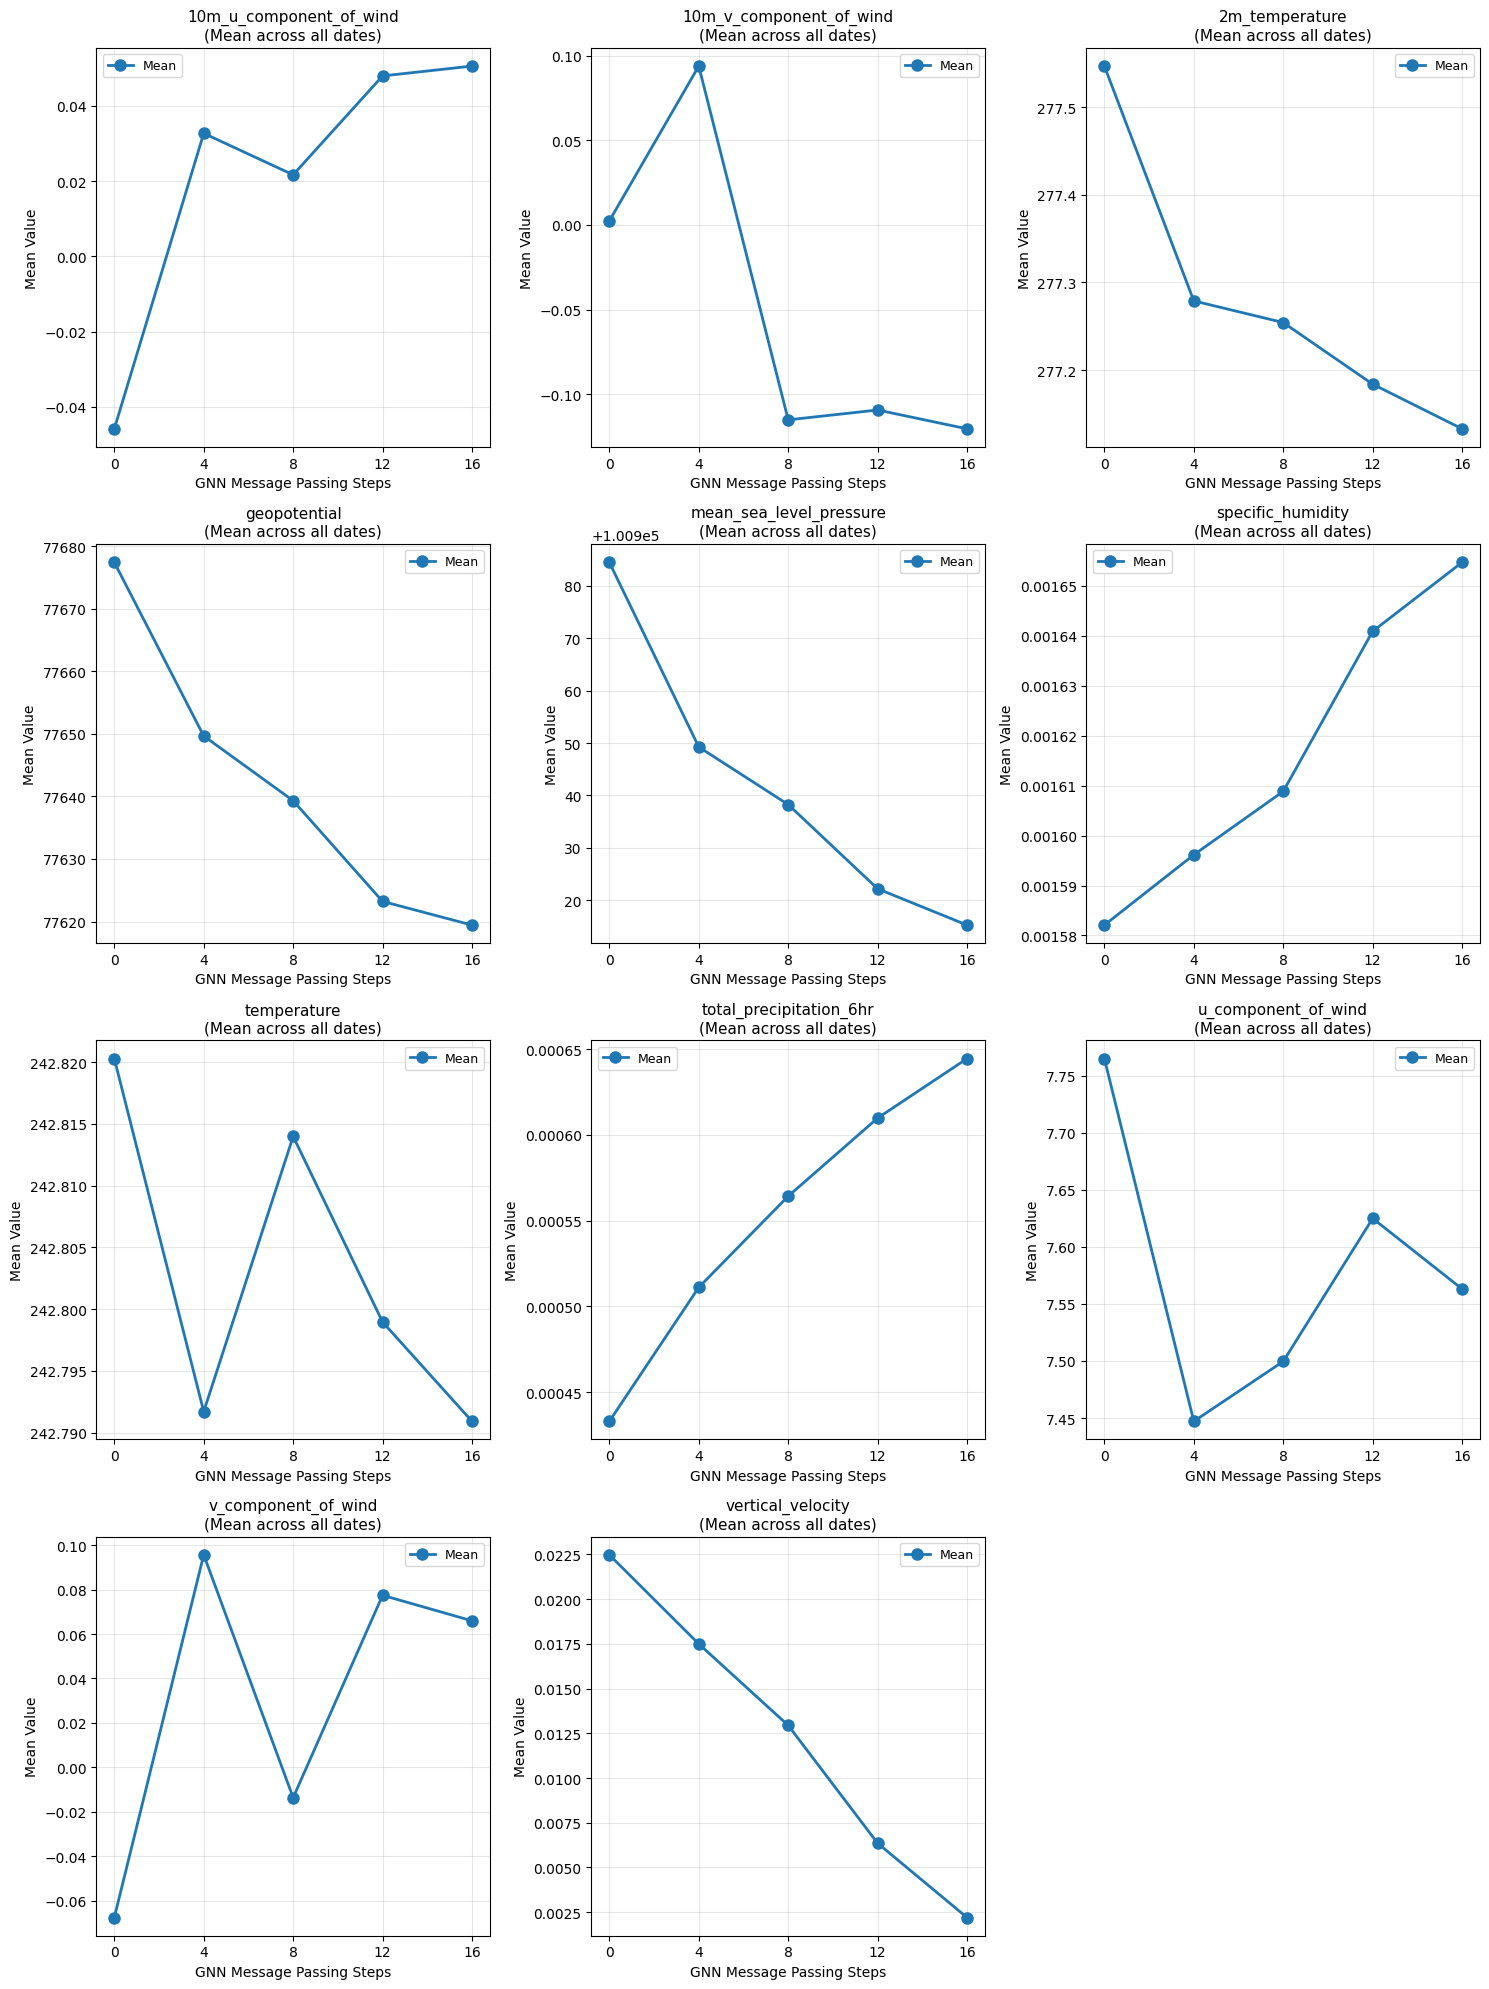

In [18]:
# 層数ごとの平均値の変化を可視化（すべての変数について）
available_vars = sorted(df_stats['variable'].unique())

if available_vars:
    n_vars = len(available_vars)
    # グリッドサイズを計算（3列で表示）
    n_cols = 3
    n_rows = (n_vars + n_cols - 1) // n_cols  # 切り上げ
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_vars > 1 else [axes]
    
    for idx, var in enumerate(available_vars):
        var_data = df_stats[df_stats['variable'] == var].sort_values('gnn_step')
        
        ax = axes[idx]
        ax.plot(var_data['gnn_step'], var_data['mean'], 'o-', label='Mean', linewidth=2, markersize=8)
        ax.set_xlabel('GNN Message Passing Steps', fontsize=10)
        ax.set_ylabel('Mean Value', fontsize=10)
        ax.set_title(f'{var}\n(Mean across all dates)', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_xticks(var_data['gnn_step'])
    
    # 未使用のaxesを非表示
    for idx in range(n_vars, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No variables found. Available variables:")
    print(df_stats['variable'].unique())


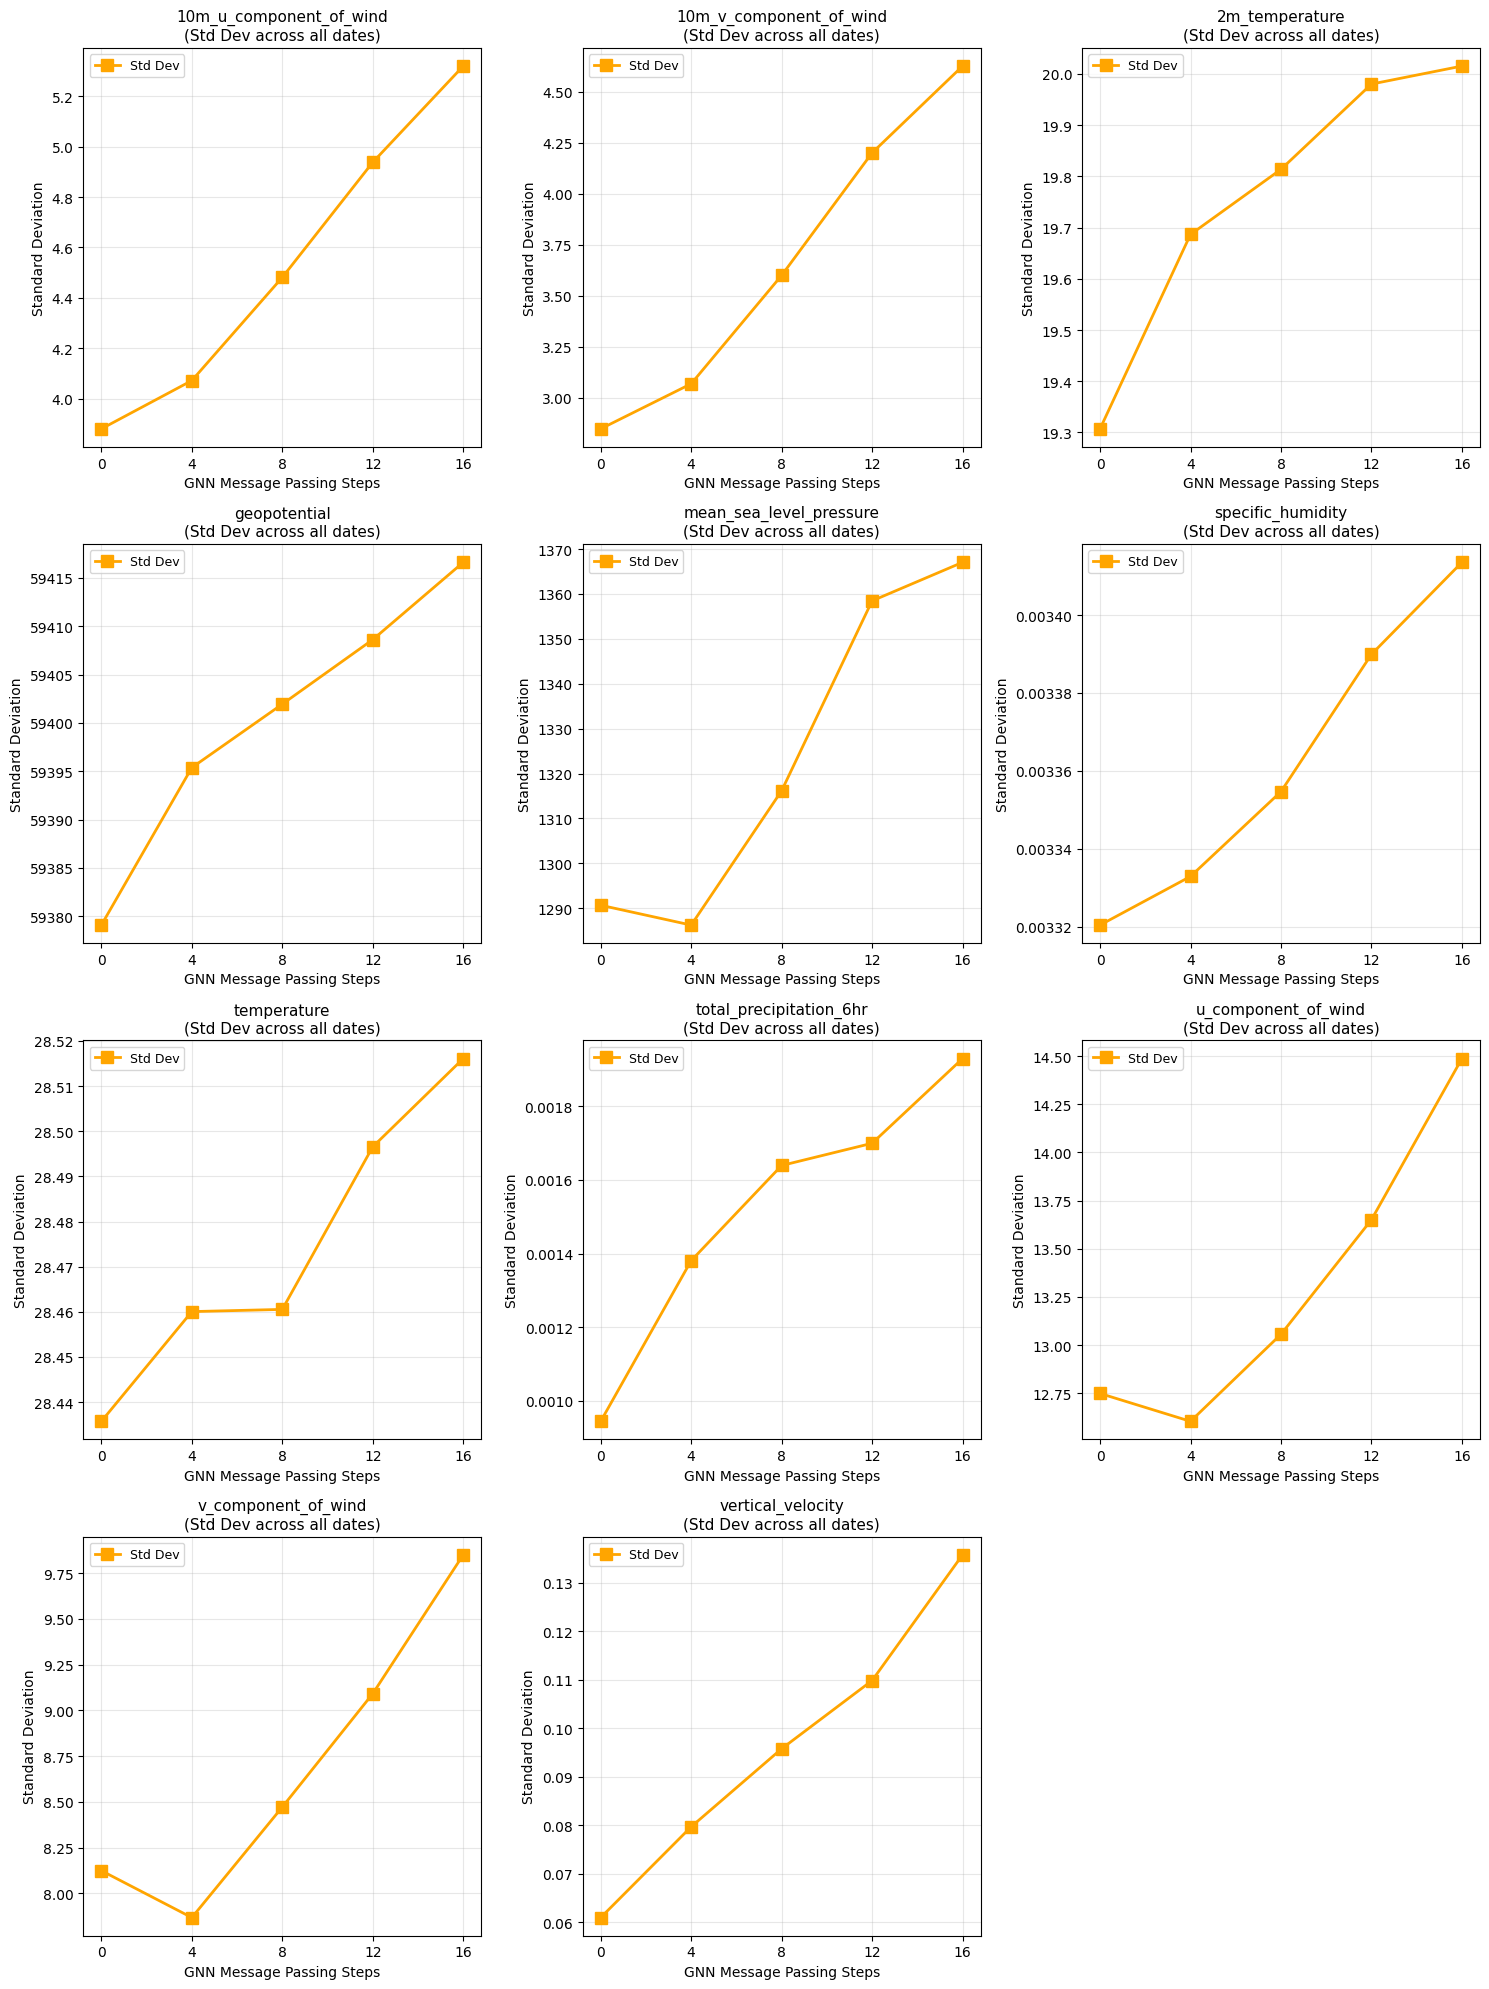

In [19]:
# 層数ごとの標準偏差の変化（予測のばらつき）- すべての変数について
if available_vars:
    n_vars = len(available_vars)
    # グリッドサイズを計算（3列で表示）
    n_cols = 3
    n_rows = (n_vars + n_cols - 1) // n_cols  # 切り上げ
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_vars > 1 else [axes]
    
    for idx, var in enumerate(available_vars):
        var_data = df_stats[df_stats['variable'] == var].sort_values('gnn_step')
        
        ax = axes[idx]
        ax.plot(var_data['gnn_step'], var_data['std'], 's-', color='orange', label='Std Dev', linewidth=2, markersize=8)
        ax.set_xlabel('GNN Message Passing Steps', fontsize=10)
        ax.set_ylabel('Standard Deviation', fontsize=10)
        ax.set_title(f'{var}\n(Std Dev across all dates)', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_xticks(var_data['gnn_step'])
    
    # 未使用のaxesを非表示
    for idx in range(n_vars, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()


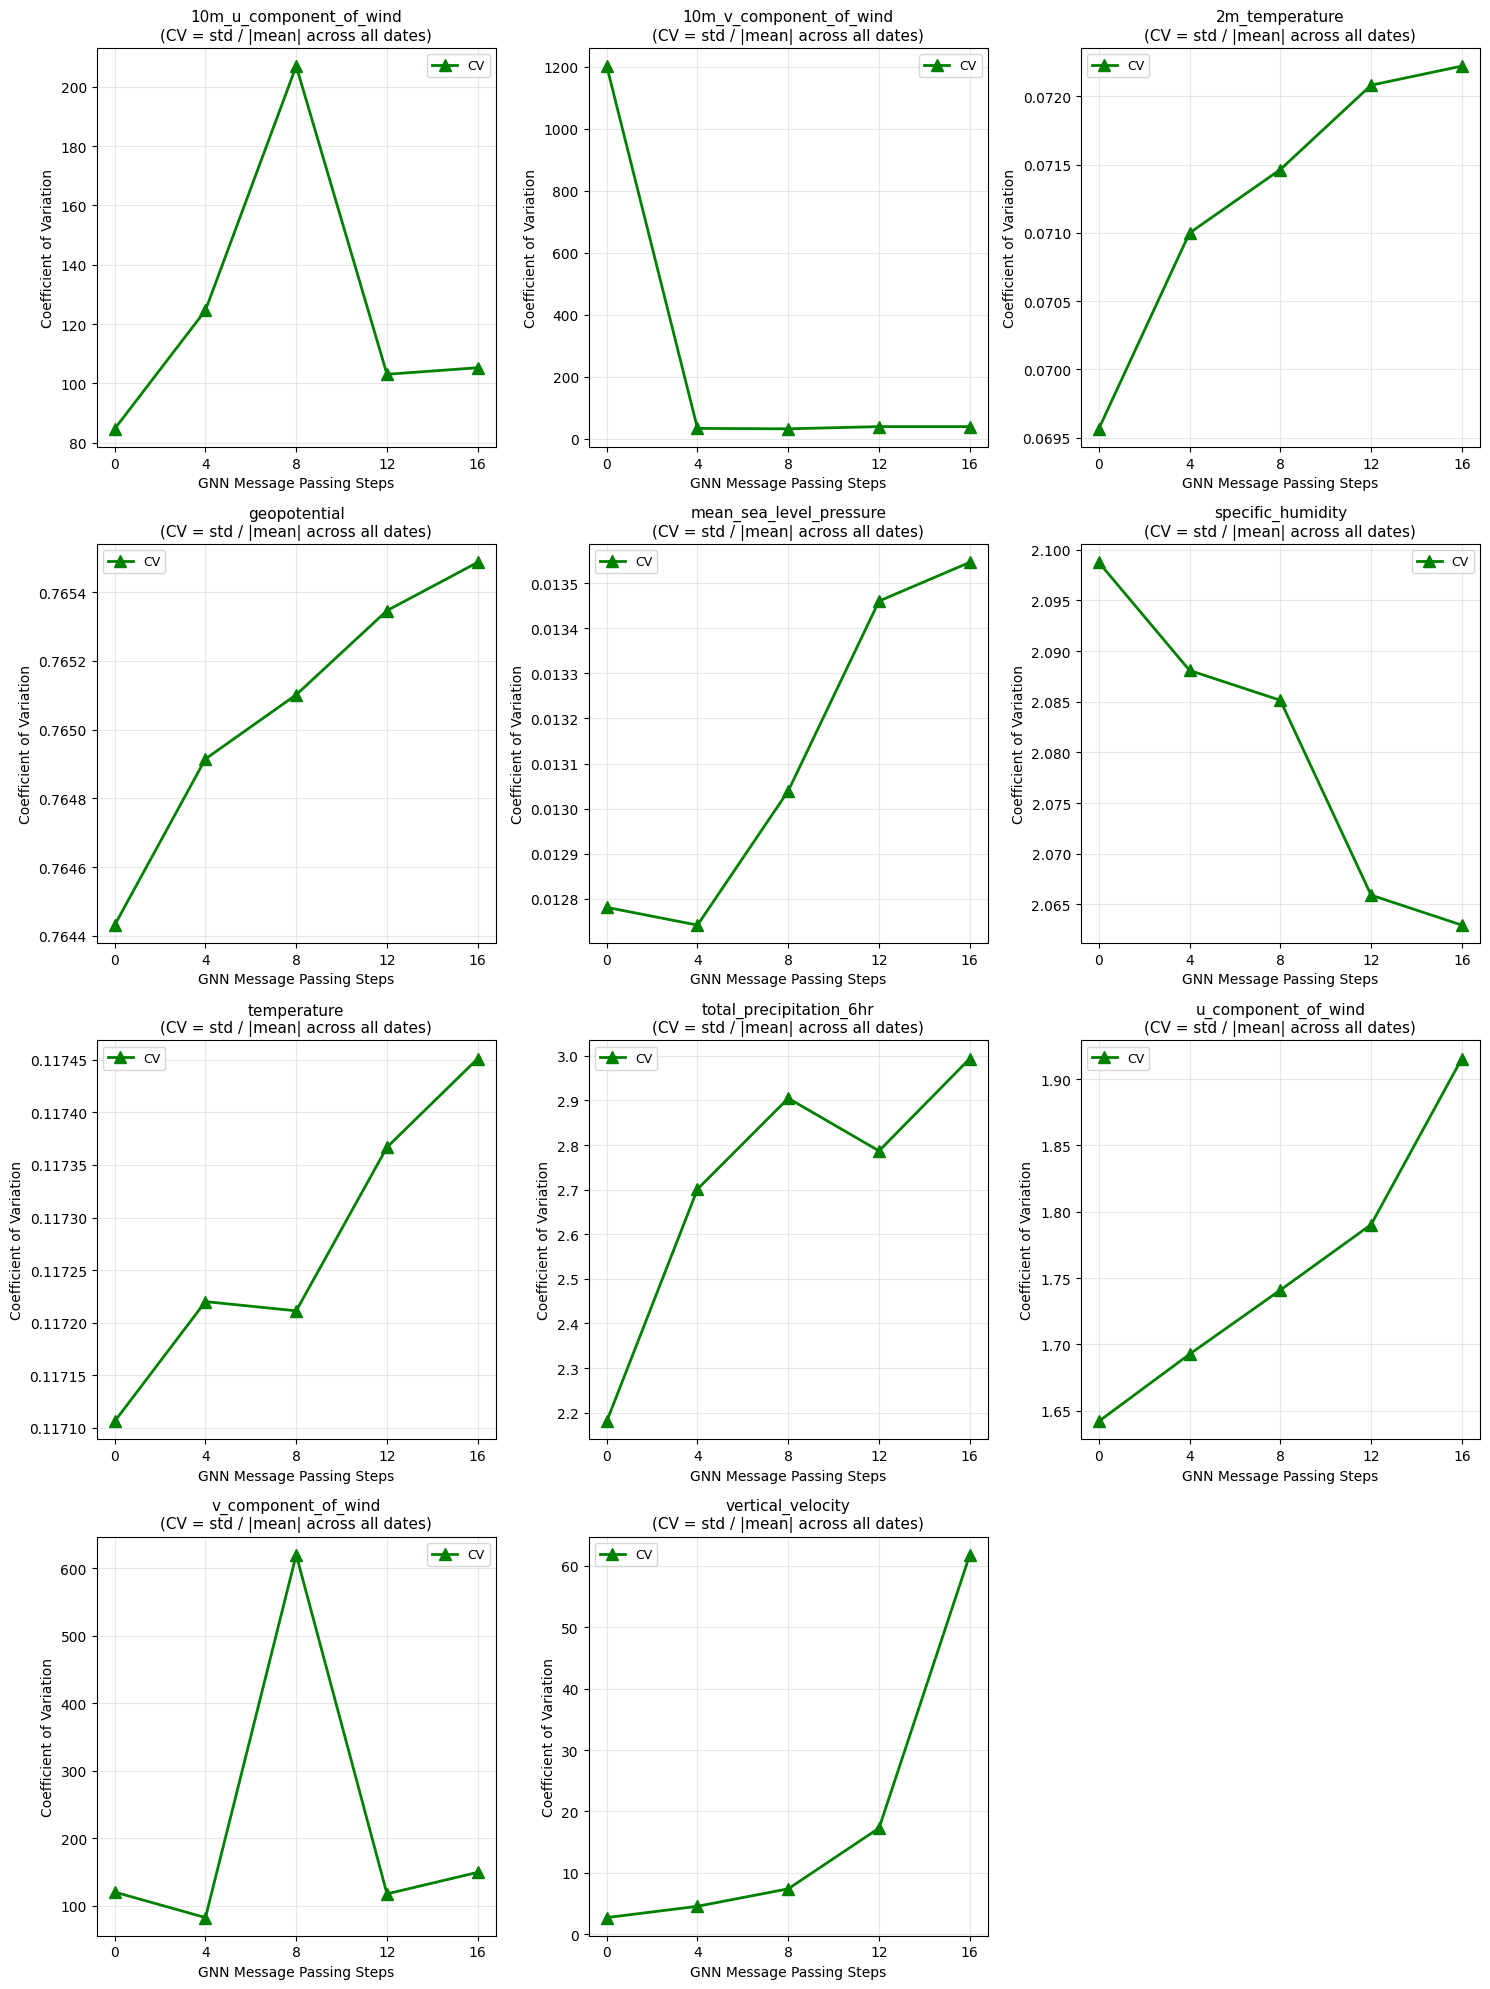


=== Coefficient of Variation Summary ===

                               mean         std        min          max
variable                                                               
10m_v_component_of_wind  268.415995  521.576850  31.236103  1201.422892
v_component_of_wind      217.824670  226.093076  82.247546   620.027111
10m_u_component_of_wind  124.916627   48.007823  84.662289   206.979894
vertical_velocity         18.750553   24.717163   2.710020    61.806743
total_precipitation_6hr    2.713515    0.318153   2.180525     2.993945
specific_humidity          2.080170    0.015274   2.062948     2.098763
u_component_of_wind        1.756225    0.104761   1.641894     1.915522
geopotential               0.765056    0.000413   0.764432     0.765486
temperature                0.117271    0.000137   0.117106     0.117451
2m_temperature             0.071266    0.001071   0.069564     0.072222
mean_sea_level_pressure    0.013114    0.000375   0.012741     0.013547


In [20]:
# 変動係数（Coefficient of Variation）の計算と可視化
# 変動係数 = std / |mean|（相対的なばらつきの指標、単位に依存しない）

# 変動係数を計算してDataFrameに追加
# 平均値が0に近い場合はNaNにする（変動係数が無限大になるのを防ぐ）
df_stats['cv'] = np.where(
    np.abs(df_stats['mean']) > 1e-10,  # 平均値が十分大きい場合のみ計算
    df_stats['std'] / np.abs(df_stats['mean']),
    np.nan
)

# すべての変数について変動係数をプロット
if available_vars:
    n_vars = len(available_vars)
    # グリッドサイズを計算（3列で表示）
    n_cols = 3
    n_rows = (n_vars + n_cols - 1) // n_cols  # 切り上げ
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_vars > 1 else [axes]
    
    for idx, var in enumerate(available_vars):
        var_data = df_stats[df_stats['variable'] == var].sort_values('gnn_step')
        # NaNを除外
        var_data_cv = var_data.dropna(subset=['cv'])
        
        ax = axes[idx]
        if len(var_data_cv) > 0:
            ax.plot(var_data_cv['gnn_step'], var_data_cv['cv'], '^-', color='green', label='CV', linewidth=2, markersize=8)
            ax.set_xlabel('GNN Message Passing Steps', fontsize=10)
            ax.set_ylabel('Coefficient of Variation', fontsize=10)
            ax.set_title(f'{var}\n(CV = std / |mean| across all dates)', fontsize=11)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=9)
            ax.set_xticks(var_data_cv['gnn_step'])
        else:
            ax.text(0.5, 0.5, f'{var}\nCV cannot be calculated\n(mean ≈ 0)', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=11)
            ax.set_title(f'{var}\n(CV calculation not available)', fontsize=11)
    
    # 未使用のaxesを非表示
    for idx in range(n_vars, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # 変動係数の統計サマリー
    print("\n=== Coefficient of Variation Summary ===\n")
    cv_summary = df_stats.groupby('variable')['cv'].agg(['mean', 'std', 'min', 'max']).sort_values('mean', ascending=False)
    print(cv_summary)
else:
    print("No variables found.")


=== Comparing all steps against reference (gnn_step=16) ===



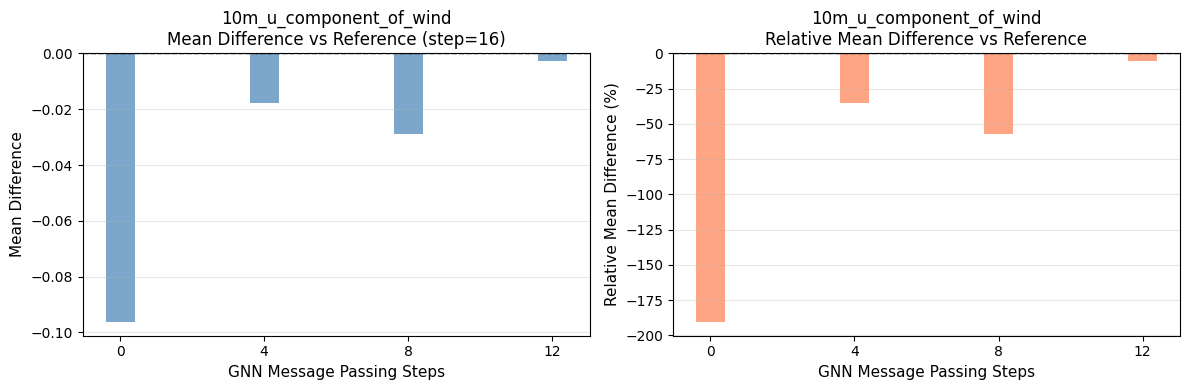

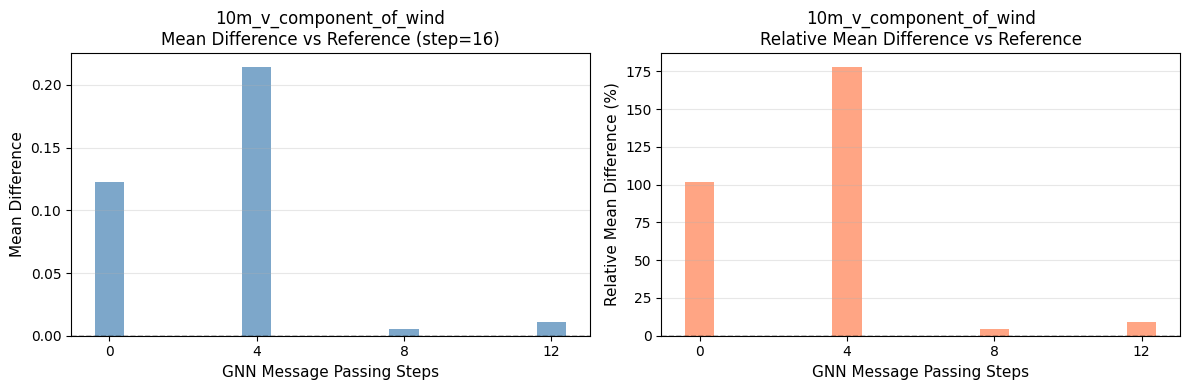

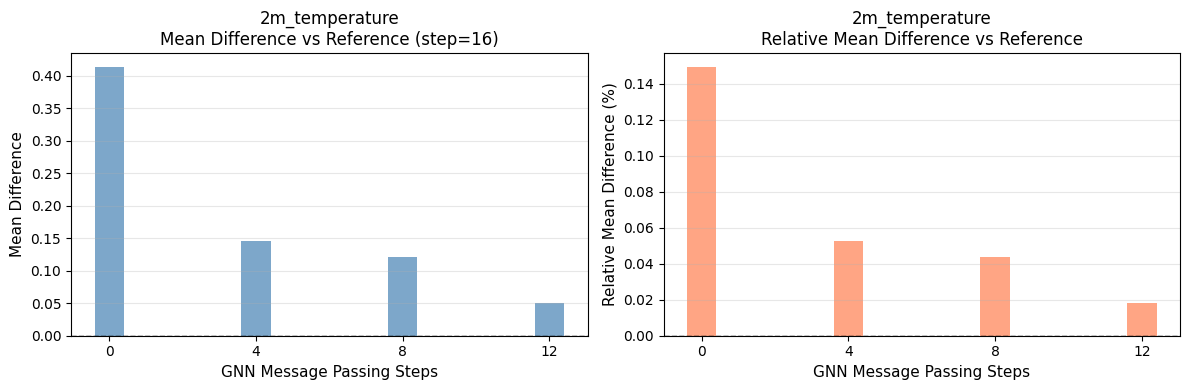


Comparison summary:
          mean_diff  rel_mean_diff_pct
gnn_step                              
0         11.618926          54.361952
4          5.864245          78.063958
8          3.898802          27.254213
12         0.986899          18.669959


In [21]:
# 層数間の差分を計算（基準層との比較）
reference_step = 16  # 基準層

if reference_step in stats_by_step:
    print(f"=== Comparing all steps against reference (gnn_step={reference_step}) ===\n")
    
    comparison_results = []
    
    for step in gnn_steps:
        if step == reference_step or step not in stats_by_step:
            continue
        
        ref_stats = stats_by_step[reference_step]
        step_stats = stats_by_step[step]
        
        for var_name in set(ref_stats.keys()) & set(step_stats.keys()):
            mean_diff = step_stats[var_name]['mean'] - ref_stats[var_name]['mean']
            std_diff = step_stats[var_name]['std'] - ref_stats[var_name]['std']
            rel_mean_diff = (mean_diff / abs(ref_stats[var_name]['mean'])) * 100 if ref_stats[var_name]['mean'] != 0 else np.nan
            
            comparison_results.append({
                'gnn_step': step,
                'variable': var_name,
                'mean_diff': mean_diff,
                'std_diff': std_diff,
                'rel_mean_diff_pct': rel_mean_diff
            })
    
    df_comparison = pd.DataFrame(comparison_results)
    
    # 主要変数について可視化
    if len(df_comparison) > 0:
        for var in available_vars[:3]:  # 最初の3つ
            var_comp = df_comparison[df_comparison['variable'] == var].sort_values('gnn_step')
            if len(var_comp) > 0:
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
                
                # 平均値の差分
                ax1.bar(var_comp['gnn_step'], var_comp['mean_diff'], alpha=0.7, color='steelblue')
                ax1.axhline(y=0, color='black', linestyle='--', linewidth=1)
                ax1.set_xlabel('GNN Message Passing Steps', fontsize=11)
                ax1.set_ylabel('Mean Difference', fontsize=11)
                ax1.set_title(f'{var}\nMean Difference vs Reference (step={reference_step})', fontsize=12)
                ax1.grid(True, alpha=0.3, axis='y')
                ax1.set_xticks(var_comp['gnn_step'])
                
                # 相対的な平均値の差分（%）
                ax2.bar(var_comp['gnn_step'], var_comp['rel_mean_diff_pct'], alpha=0.7, color='coral')
                ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
                ax2.set_xlabel('GNN Message Passing Steps', fontsize=11)
                ax2.set_ylabel('Relative Mean Difference (%)', fontsize=11)
                ax2.set_title(f'{var}\nRelative Mean Difference vs Reference', fontsize=12)
                ax2.grid(True, alpha=0.3, axis='y')
                ax2.set_xticks(var_comp['gnn_step'])
                
                plt.tight_layout()
                plt.show()
    
    print(f"\nComparison summary:")
    print(df_comparison.groupby('gnn_step')[['mean_diff', 'rel_mean_diff_pct']].mean())


In [22]:
# 統計結果のサマリーテーブル（主要変数）
if len(df_stats) > 0:
    summary_vars = available_vars[:5] if len(available_vars) >= 5 else available_vars
    
    print("=== Summary Statistics by GNN Step ===\n")
    for var in summary_vars:
        var_data = df_stats[df_stats['variable'] == var].sort_values('gnn_step')
        print(f"\n{var}:")
        print(var_data[['gnn_step', 'mean', 'std', 'min', 'max', 'median']].to_string(index=False))
        print("-" * 80)


=== Summary Statistics by GNN Step ===


10m_u_component_of_wind:
 gnn_step      mean      std        min       max    median
        0 -0.045827 3.879831 -16.024124 19.009018 -0.227025
        4  0.032671 4.071442 -19.873543 22.343906 -0.148092
        8  0.021650 4.481174 -25.678171 22.745035 -0.150369
       12  0.047919 4.938100 -28.176584 25.264887 -0.172475
       16  0.050536 5.319971 -28.666067 28.398853 -0.228742
--------------------------------------------------------------------------------

10m_v_component_of_wind:
 gnn_step      mean      std        min       max    median
        0  0.002370 2.847220 -14.917553 14.148545 -0.001616
        4  0.093917 3.068028 -15.074739 15.308448  0.078493
        8 -0.115228 3.599262 -20.437397 18.981836 -0.108805
       12 -0.109409 4.199595 -25.215872 22.045769 -0.141067
       16 -0.120537 4.624913 -26.615187 26.861034 -0.135845
--------------------------------------------------------------------------------

2m_temperature:
 gnn_step

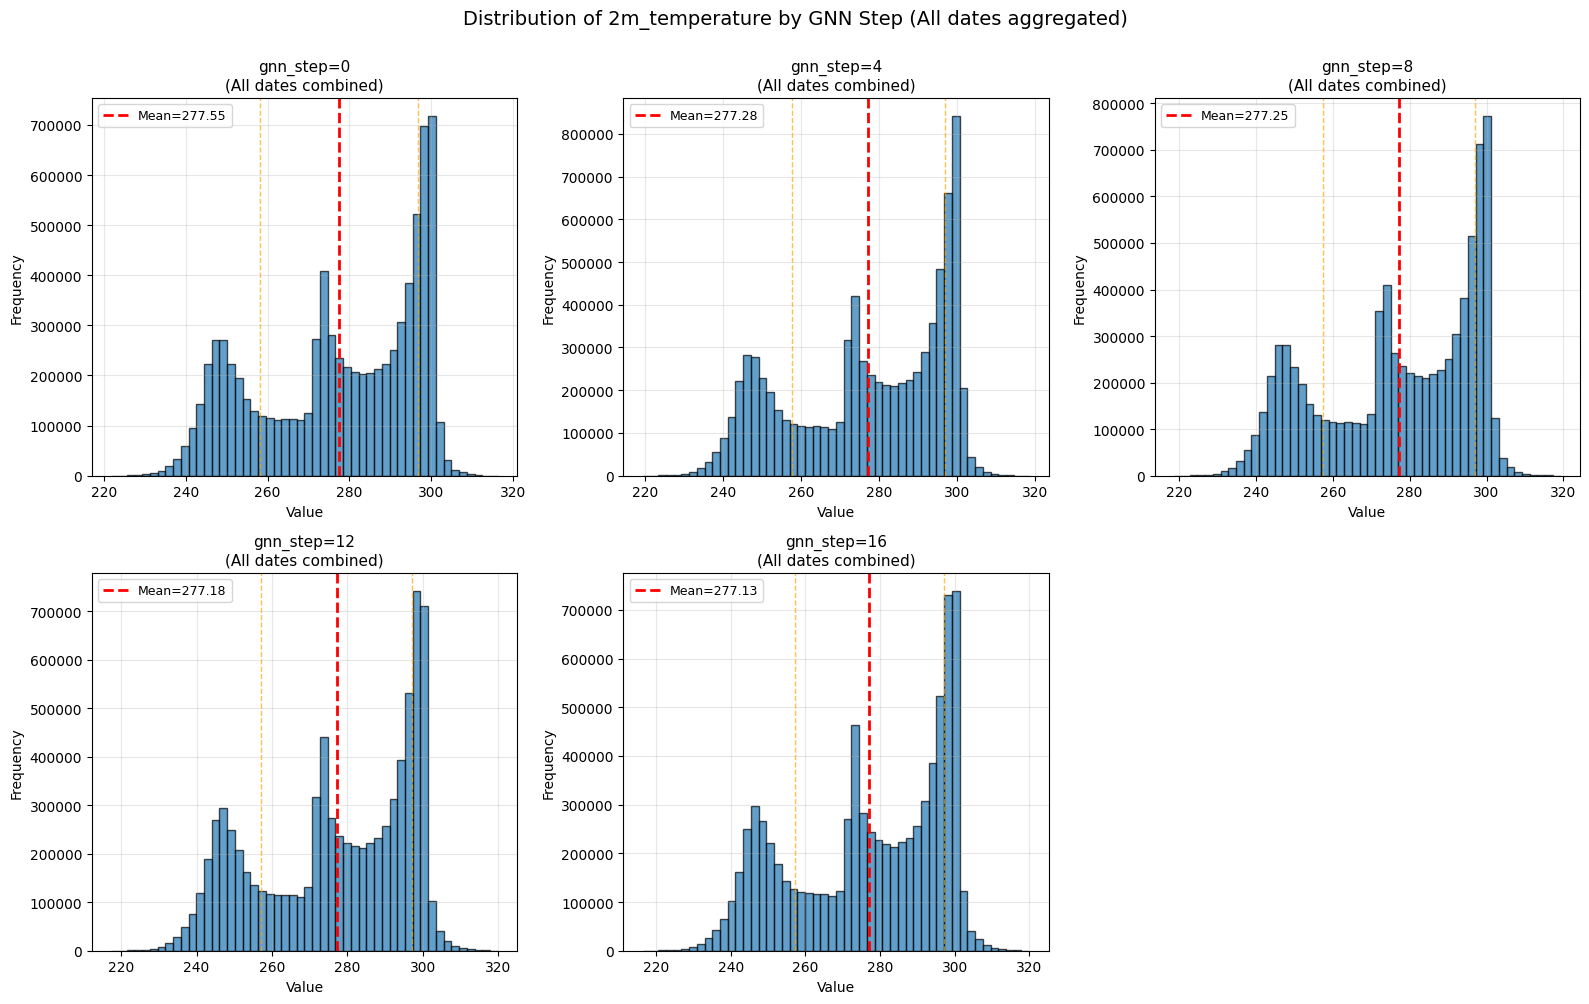

In [23]:
# 層数ごとの分布の可視化（ヒストグラム）
# 例として、2m_temperature の分布を比較
target_var = '2m_temperature'

if target_var in [v for step_data in data_by_step.values() for v in step_data.data_vars]:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, step in enumerate(sorted(data_by_step.keys())):
        if idx >= len(axes):
            break
        
        ds = data_by_step[step]
        if target_var in ds.data_vars:
            var_data = ds[target_var].values.flatten()
            var_data = var_data[~np.isnan(var_data)]
            
            ax = axes[idx]
            ax.hist(var_data, bins=50, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Value', fontsize=10)
            ax.set_ylabel('Frequency', fontsize=10)
            ax.set_title(f'gnn_step={step}\n(All dates combined)', fontsize=11)
            ax.grid(True, alpha=0.3)
            
            # 統計情報をテキストで表示
            mean_val = np.mean(var_data)
            std_val = np.std(var_data)
            ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean={mean_val:.2f}')
            ax.axvline(mean_val + std_val, color='orange', linestyle='--', linewidth=1, alpha=0.7)
            ax.axvline(mean_val - std_val, color='orange', linestyle='--', linewidth=1, alpha=0.7)
            ax.legend(fontsize=9)
    
    # 未使用のaxesを非表示
    for idx in range(len(sorted(data_by_step.keys())), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f'Distribution of {target_var} by GNN Step (All dates aggregated)', fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()
else:
    print(f"Variable '{target_var}' not found. Available variables:")
    if data_by_step:
        print(list(list(data_by_step.values())[0].data_vars.keys()))


## 分析結果のまとめ

このノートブックでは、各GNN層数（gnn_msg_steps）ごとに、すべての日付のデータを集約して統計特徴を計算しました。

### 主な分析内容
1. **層ごとの集約統計**: 各層について、すべての日付をまとめて平均、標準偏差、分位数などを計算
2. **層間の比較**: 異なる層数間での統計特徴の変化を可視化
3. **分布の比較**: 層数ごとの値の分布をヒストグラムで比較

### 次のステップ
- 特定の変数に焦点を当てた詳細分析
- 空間パターンの層間比較
- 予測精度との関連性分析
